# Capstone Hito 1: F1 Race Strategy Baseline
Group 13: Adrean Torres, Benjamín Pinto


In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, f1_score, roc_auc_score
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('f1_strategy_race_level.csv')
print(f"Loaded dataset with {len(df)} records.")


Loaded dataset with 2447 records.


## 1. Temporal Split
Train: 2019–2021 | Calibration: 2022 | Test: 2023–2024


In [5]:
# Define splits based on season
train_mask = df['season'].isin([2019, 2020, 2021])
calib_mask = df['season'] == 2022
test_mask = df['season'].isin([2023, 2024])

train_df = df[train_mask].copy()
calib_df = df[calib_mask].copy()
test_df = df[test_mask].copy()

# Verify no test rows in train
assert not train_df['season'].isin([2023, 2024]).any(), "Test data leaked into train!"

print(f"Train rows: {len(train_df)}")
print(f"Calibration rows: {len(calib_df)}")
print(f"Test rows: {len(test_df)}")


Train rows: 1132
Calibration rows: 426
Test rows: 889


## 2. Leakage Audit

| Feature | Category | Notes |
|---------|----------|-------|
| `grid_position` | **Pre-race available** | Used when available because penalties can change the starting grid after qualifying. |
| `qualifying_position` | **Pre-race available (proxy)** | Used only if `grid_position` is missing. We create `grid_position_effective` to enforce this rule. |
| `constructor_tier` | **Pre-race available** | Known based on team pace context heading into the race weekend. |
| `n_stops` | **Scenario Input (Post-race observed)** | Post-race observation. Only permitted for what-if scenario testing. Not a true pre-race feature. |
| `compound_sequence` | **Scenario Input (Post-race observed)** | Same as above, used specifically for scenario generation. |

*Note*: Incident features (`safety_car_periods`, `weather_actual`) are not used in these pre-race modeling pipelines to avoid target leakage.


## 3. Baseline Model (2 features)
Features: `grid_position_effective`, `constructor_tier`
Target: `is_top10`


--- Baseline Performance on Test ---
Brier Score: 0.1431 (Docent calibrated reference: 0.132, Docent grid-rule reference: 0.208)
Log Loss: 0.4502
ROC-AUC: 0.8736
Macro F1: 0.8007


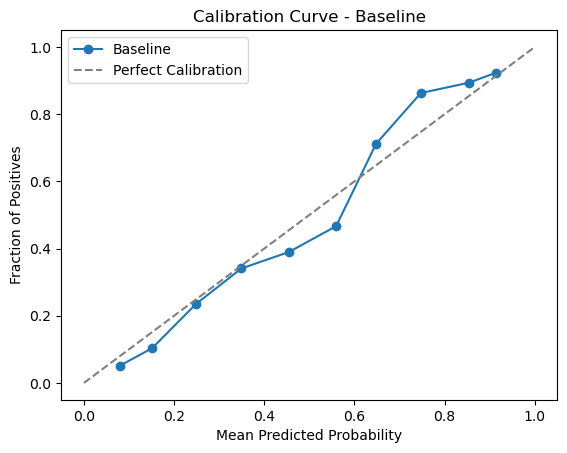

In [7]:
from sklearn.calibration import CalibratedClassifierCV

def build_grid_position_effective(frame):
    if 'grid_position' in frame.columns:
        return frame['grid_position'].where(frame['grid_position'].notna(), frame['qualifying_position'])
    return frame['qualifying_position']

train_df['grid_position_effective'] = build_grid_position_effective(train_df)
calib_df['grid_position_effective'] = build_grid_position_effective(calib_df)
test_df['grid_position_effective'] = build_grid_position_effective(test_df)

features_baseline = ['grid_position_effective', 'constructor_tier']
target = 'is_top10'

# Preprocessing
preprocessor_baseline = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['grid_position_effective']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['constructor_tier'])
    ])

# Base Model
base_lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Pipeline
baseline_pipe = Pipeline(steps=[('preprocessor', preprocessor_baseline),
                                ('classifier', base_lr)])

# Train on 2019-2021
baseline_pipe.fit(train_df[features_baseline], train_df[target])

# Platt Scaling on 2022 Calibration Set
calibrated_baseline = CalibratedClassifierCV(estimator=baseline_pipe, method='sigmoid', cv='prefit')
calibrated_baseline.fit(calib_df[features_baseline], calib_df[target])

# Evaluate on Test (2023-2024)
X_test_base = test_df[features_baseline]
y_test = test_df[target]

preds_prob_base = calibrated_baseline.predict_proba(X_test_base)[:, 1]
preds_class_base = calibrated_baseline.predict(X_test_base)

brier_base = brier_score_loss(y_test, preds_prob_base)
ll_base = log_loss(y_test, preds_prob_base)
roc_auc_base = roc_auc_score(y_test, preds_prob_base)
macro_f1_base = f1_score(y_test, preds_class_base, average='macro')

print(f"--- Baseline Performance on Test ---")
print(f"Brier Score: {brier_base:.4f} (Docent calibrated reference: 0.132, Docent grid-rule reference: 0.208)")
print(f"Log Loss: {ll_base:.4f}")
print(f"ROC-AUC: {roc_auc_base:.4f}")
print(f"Macro F1: {macro_f1_base:.4f}")

# Calibration Curve
prob_true_base, prob_pred_base = calibration_curve(y_test, preds_prob_base, n_bins=10)
plt.plot(prob_pred_base, prob_true_base, marker='o', label='Baseline')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve - Baseline')
plt.legend()
plt.show()


## 4. Experiment 1 (3 features)
Features: `grid_position_effective`, `constructor_tier`, `n_stops`


In [8]:
features_exp1 = ['grid_position_effective', 'constructor_tier', 'n_stops']

preprocessor_exp1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['grid_position_effective', 'n_stops']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['constructor_tier'])
    ])

exp1_pipe = Pipeline(steps=[('preprocessor', preprocessor_exp1),
                            ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))])

exp1_pipe.fit(train_df[features_exp1], train_df[target])

calibrated_exp1 = CalibratedClassifierCV(estimator=exp1_pipe, method='sigmoid', cv='prefit')
calibrated_exp1.fit(calib_df[features_exp1], calib_df[target])

X_test_exp1 = test_df[features_exp1]
preds_prob_exp1 = calibrated_exp1.predict_proba(X_test_exp1)[:, 1]
preds_class_exp1 = calibrated_exp1.predict(X_test_exp1)

brier_exp1 = brier_score_loss(y_test, preds_prob_exp1)
roc_auc_exp1 = roc_auc_score(y_test, preds_prob_exp1)
macro_f1_exp1 = f1_score(y_test, preds_class_exp1, average='macro')

print(f"--- Experiment 1 Performance on Test ---")
print(f"Brier Score: {brier_exp1:.4f}")
print(f"ROC-AUC: {roc_auc_exp1:.4f}")
print(f"Macro F1: {macro_f1_exp1:.4f}")
print(f"Difference vs Baseline Brier: {brier_exp1 - brier_base:.4f}")


--- Experiment 1 Performance on Test ---
Brier Score: 0.1436
ROC-AUC: 0.8728
Macro F1: 0.7950
Difference vs Baseline Brier: 0.0005


## 5. Experiment 2 (4 features)
Features: `grid_position_effective`, `constructor_tier`, `n_stops`, `compound_sequence`
Encoding compound_sequence as number of distinct compounds used.


In [9]:
# Feature engineering: encode compound_sequence as distinct count
def count_unique_compounds(seq):
    if pd.isna(seq):
        return 1  # Fallback to 1 compound if missing
    return len(set(seq.split('-')))

train_df['num_compounds'] = train_df['compound_sequence'].apply(count_unique_compounds)
calib_df['num_compounds'] = calib_df['compound_sequence'].apply(count_unique_compounds)
test_df['num_compounds'] = test_df['compound_sequence'].apply(count_unique_compounds)

features_exp2 = ['grid_position_effective', 'constructor_tier', 'n_stops', 'num_compounds']

preprocessor_exp2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['grid_position_effective', 'n_stops', 'num_compounds']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), ['constructor_tier'])
    ])

exp2_pipe = Pipeline(steps=[('preprocessor', preprocessor_exp2),
                            ('classifier', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))])

exp2_pipe.fit(train_df[features_exp2], train_df[target])

calibrated_exp2 = CalibratedClassifierCV(estimator=exp2_pipe, method='sigmoid', cv='prefit')
calibrated_exp2.fit(calib_df[features_exp2], calib_df[target])

X_test_exp2 = test_df[features_exp2]
preds_prob_exp2 = calibrated_exp2.predict_proba(X_test_exp2)[:, 1]
preds_class_exp2 = calibrated_exp2.predict(X_test_exp2)

brier_exp2 = brier_score_loss(y_test, preds_prob_exp2)
roc_auc_exp2 = roc_auc_score(y_test, preds_prob_exp2)
macro_f1_exp2 = f1_score(y_test, preds_class_exp2, average='macro')

print(f"--- Experiment 2 Performance on Test ---")
print(f"Brier Score: {brier_exp2:.4f}")
print(f"ROC-AUC: {roc_auc_exp2:.4f}")
print(f"Macro F1: {macro_f1_exp2:.4f}")
print(f"Difference vs Baseline Brier: {brier_exp2 - brier_base:.4f}")


--- Experiment 2 Performance on Test ---
Brier Score: 0.1442
ROC-AUC: 0.8721
Macro F1: 0.7973
Difference vs Baseline Brier: 0.0011


## 6. What-If Scenarios
Using **Experiment 2 (4 features)** because it incorporates both `n_stops` and `compound_sequence` (as `num_compounds`).

Scenario protocol (Hito 2):
1) Fix pre-race inputs first (use `grid_position` when available; otherwise fall back to `qualifying_position`).
2) Set user-controlled strategy inputs (`n_stops`, `compound_sequence`) explicitly.
3) Report outputs as **scenario-conditioned estimates** $P(is\_top10 \mid \text{inputs})$ (not causal effects).

- **Scenario A**: grid_position_effective=4, constructor_tier='front', n_stops=1, num_compounds=2 (M-H)
- **Scenario B**: grid_position_effective=4, constructor_tier='front', n_stops=2, num_compounds=3 (S-M-H)


In [10]:
from sklearn.utils import resample

# Base scenario definitions (scenario-conditioned estimates, not causal effects)
scenario_A = pd.DataFrame([{
    'grid_position_effective': 4.0,
    'constructor_tier': 'front',
    'n_stops': 1,
    'num_compounds': 2
}])

scenario_B = pd.DataFrame([{
    'grid_position_effective': 4.0,
    'constructor_tier': 'front',
    'n_stops': 2,
    'num_compounds': 3
}])

# Point estimate using the calibrated model fitted on full calib set
prob_A_point = calibrated_exp2.predict_proba(scenario_A)[0, 1]
prob_B_point = calibrated_exp2.predict_proba(scenario_B)[0, 1]
diff_point = prob_A_point - prob_B_point

print("Point Estimates (scenario-conditioned, not causal):")
print(f"P(is_top10 | Scenario A, 1-stop M-H): {prob_A_point:.4f}")
print(f"P(is_top10 | Scenario B, 2-stop S-M-H): {prob_B_point:.4f}")
print(f"Difference (A - B): {diff_point:.4f}\n")

# Bootstrap 90% CI
n_bootstraps = 1000
diffs = []

print("Running bootstrap resamples...")
for i in range(n_bootstraps):
    # Resample training data
    boot_train = resample(train_df, random_state=i)
    
    # Fit pipeline
    boot_pipe = Pipeline(steps=[('preprocessor', preprocessor_exp2),
                                ('classifier', LogisticRegression(class_weight='balanced', random_state=i, max_iter=1000))])
    boot_pipe.fit(boot_train[features_exp2], boot_train[target])
    
    # Calibrate on the SAME calib set
    boot_calib = CalibratedClassifierCV(estimator=boot_pipe, method='sigmoid', cv='prefit')
    boot_calib.fit(calib_df[features_exp2], calib_df[target])
    
    # Predict scenarios
    pA = boot_calib.predict_proba(scenario_A)[0, 1]
    pB = boot_calib.predict_proba(scenario_B)[0, 1]
    
    diffs.append(pA - pB)

# Calculate 90% CI
ci_lower = np.percentile(diffs, 5)
ci_upper = np.percentile(diffs, 95)

print(f"Bootstrap 90% CI for Scenario-Conditioned Difference in P(is_top10): [{ci_lower:.4f}, {ci_upper:.4f}]")
if ci_lower <= 0 <= ci_upper:
    print("Conclusion: Confidence intervals overlap zero, the scenario difference is NOT statistically significant.")
else:
    print("Conclusion: The scenario difference IS statistically significant at 90% confidence level.")


Point Estimates (scenario-conditioned, not causal):
P(is_top10 | Scenario A, 1-stop M-H): 0.8660
P(is_top10 | Scenario B, 2-stop S-M-H): 0.8931
Difference (A - B): -0.0271

Running bootstrap resamples...
Bootstrap 90% CI for Scenario-Conditioned Difference in P(is_top10): [-0.0558, 0.0024]
Conclusion: Confidence intervals overlap zero, the scenario difference is NOT statistically significant.


## 7. Fallback Conclusion

```python
if brier_base < 0.132:
    print("Outperforms the instructor's model. Ready to inform pit wall decisions.")
elif brier_base < 0.208:
    print("Outperforms the grid-rule baseline, but not the instructor's model. Use with caution or as a pre-race exploratory tool.")
else:
    print("Brier ≥ 0.208. The model is NOT recommended for real-time pit wall decisions. Its use should be restricted exclusively to exploratory pre-race simulations (What-If), as it is not sufficiently robust.")

```


In [11]:
if brier_base < 0.132:
    conclusion = "Outperforms the instructor's model. Ready to inform pit wall decisions."
elif brier_base < 0.208:
    conclusion = "Outperforms the grid-rule baseline, but not the instructor's model. Use with caution or as a pre-race exploratory tool."
else:
    conclusion = "Brier ≥ 0.208. The model is NOT recommended for real-time pit wall decisions. Its use should be restricted exclusively to exploratory pre-race simulations (What-If), as it is not sufficiently robust."

print("Fallback Conclusion Evaluation:")
print(conclusion)

Fallback Conclusion Evaluation:
Outperforms the grid-rule baseline, but not the instructor's model. Use with caution or as a pre-race exploratory tool.
